<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [3]:
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,64.806745,0.973646,8.093204,34.608419,1514.742484,173.215209,5.839639,78.673451,0.001593,0.649221,Pump,Electrical,Fan Blade
1,86.601363,0.548551,3.186354,65.476655,1757.584027,132.811770,8.812131,67.858210,0.611290,26.747214,Motor,"Vibration, Wear",Fan Blade
2,42.183374,0.176440,5.955282,74.556018,4936.173087,118.421218,2.103344,67.128614,0.310995,21.232180,Turbine,Electrical,Seal
3,21.720388,0.448342,2.331397,55.139809,2966.420634,187.440635,3.360184,91.632058,0.182024,55.494646,Compressor,Electrical,Gear
4,68.527639,0.296086,3.695622,53.819778,3395.388633,198.839561,8.930478,98.875357,0.987028,2.095609,Turbine,"Vibration, Wear",Bearing


In [4]:
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,41.923668,0.176243,7.274595,33.151194,1666.553261,215.447795,8.765274,92.329572,0.014847,71.479551,Compressor,Electrical,Seal
96,97.754032,0.811749,3.778200,37.490406,1950.060552,181.993698,6.213439,91.356989,0.871289,77.043485,Pump,Electrical,Bearing
97,32.114704,0.640106,4.816164,55.991323,2517.921198,149.009703,2.050384,94.171890,0.749246,23.197087,Turbine,"Vibration, Wear",Bearing
98,32.233223,0.579645,8.069424,66.717783,1577.506491,117.011308,3.203699,62.690706,0.741883,11.482986,Pump,Overheating,Gear
99,86.155312,0.293708,2.379567,70.200110,4029.843607,142.533001,8.387373,78.641219,0.989893,28.292166,Compressor,Electrical,Bearing


# **Exploratory Data Analysis**

In [5]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [6]:
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,59.517972,0.516247,5.519580,56.056341,2815.564951,169.025540,5.780644,79.917436,0.465667,47.369080
std,23.352745,0.290271,2.525841,13.982115,1107.453898,36.322084,2.526629,10.937854,0.284523,29.741460
min,21.683217,0.008384,1.016146,33.151194,1004.599810,110.200134,1.126550,60.063807,0.001593,0.137384
25%,40.717742,0.273877,3.174239,44.331095,1793.726612,139.300497,3.440831,71.855681,0.209766,21.445487
50%,57.793265,0.538115,5.670384,54.502333,2828.330161,169.079968,5.863111,79.095589,0.468906,43.581323
75%,80.212445,0.736500,7.417635,68.275907,3629.601390,198.862979,8.098215,88.811463,0.720637,72.901935
max,99.088269,0.988842,9.899165,79.964708,4936.173087,239.051387,9.743352,99.114923,0.991240,99.806365


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000   0.037220  0.037643 -0.006654  0.115179 -0.164318   
Vibration       0.037220   1.000000 -0.183550 -0.065038 -0.140205 -0.009918   
Pressure        0.037643  -0.183550  1.000000 -0.010233  0.057607 -0.160570   
Humidity       -0.006654  -0.065038 -0.010233  1.000000 -0.106459 -0.033381   
RPM             0.115179  -0.140205  0.057607 -0.106459  1.000000 -0.243647   
Voltage        -0.164318  -0.009918 -0.160570 -0.033381 -0.243647  1.000000   
Current         0.088325   0.023748 -0.117688 -0.078210 -0.012133  0.091055   
Sound_Level    -0.067567  -0.216553  0.249147 -0.133488  0.105948 -0.029609   
Oil_Quality     0.004839   0.107386 -0.104524  0.081050 -0.049722  0.006870   
Load            0.278908   0.012234  0.023777  0.055983 -0.020304  0.051611   

              Current  Sound_Level  Oil_Quality      Load  
Temperature  0.088325    -0.067567     0.004839  0.278908  
Vibration 

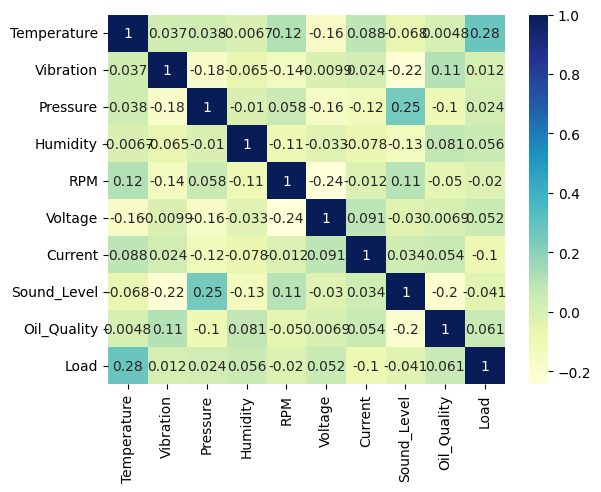

In [7]:
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

# **Random Forest**

In [8]:
for col in pred:
  if pred[col].dtype == 'O':
    codes, _ = pd.factorize(pred[col])
    pred[col] = codes

In [9]:
X = pred[['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality','Load',
          'Failure Type','Component Type','Machine Type']]
y = pred['Component Type']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Recall: 1.0
Precision: 1.0
F1 Score: 1.0
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

